In [4]:
import os 
import tarfile
from six.moves import urllib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

In [8]:
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
     if not os.path.isdir(housing_path):
         os.makedirs(housing_path)
     tgz_path = os.path.join(housing_path, "housing.tgz")
     urllib.request.urlretrieve(housing_url, tgz_path)
     housing_tgz = tarfile.open(tgz_path)
     housing_tgz.extractall(path=housing_path)
     housing_tgz.close()

fetch_housing_data()

In [9]:

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path,"housing.csv")
    return pd.read_csv(csv_path)
housing =load_housing_data()

# Let's take a Quick Look at the Dataset


In [10]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [11]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [12]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [13]:
housing.describe()# shows the summary of the numerical attribute

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


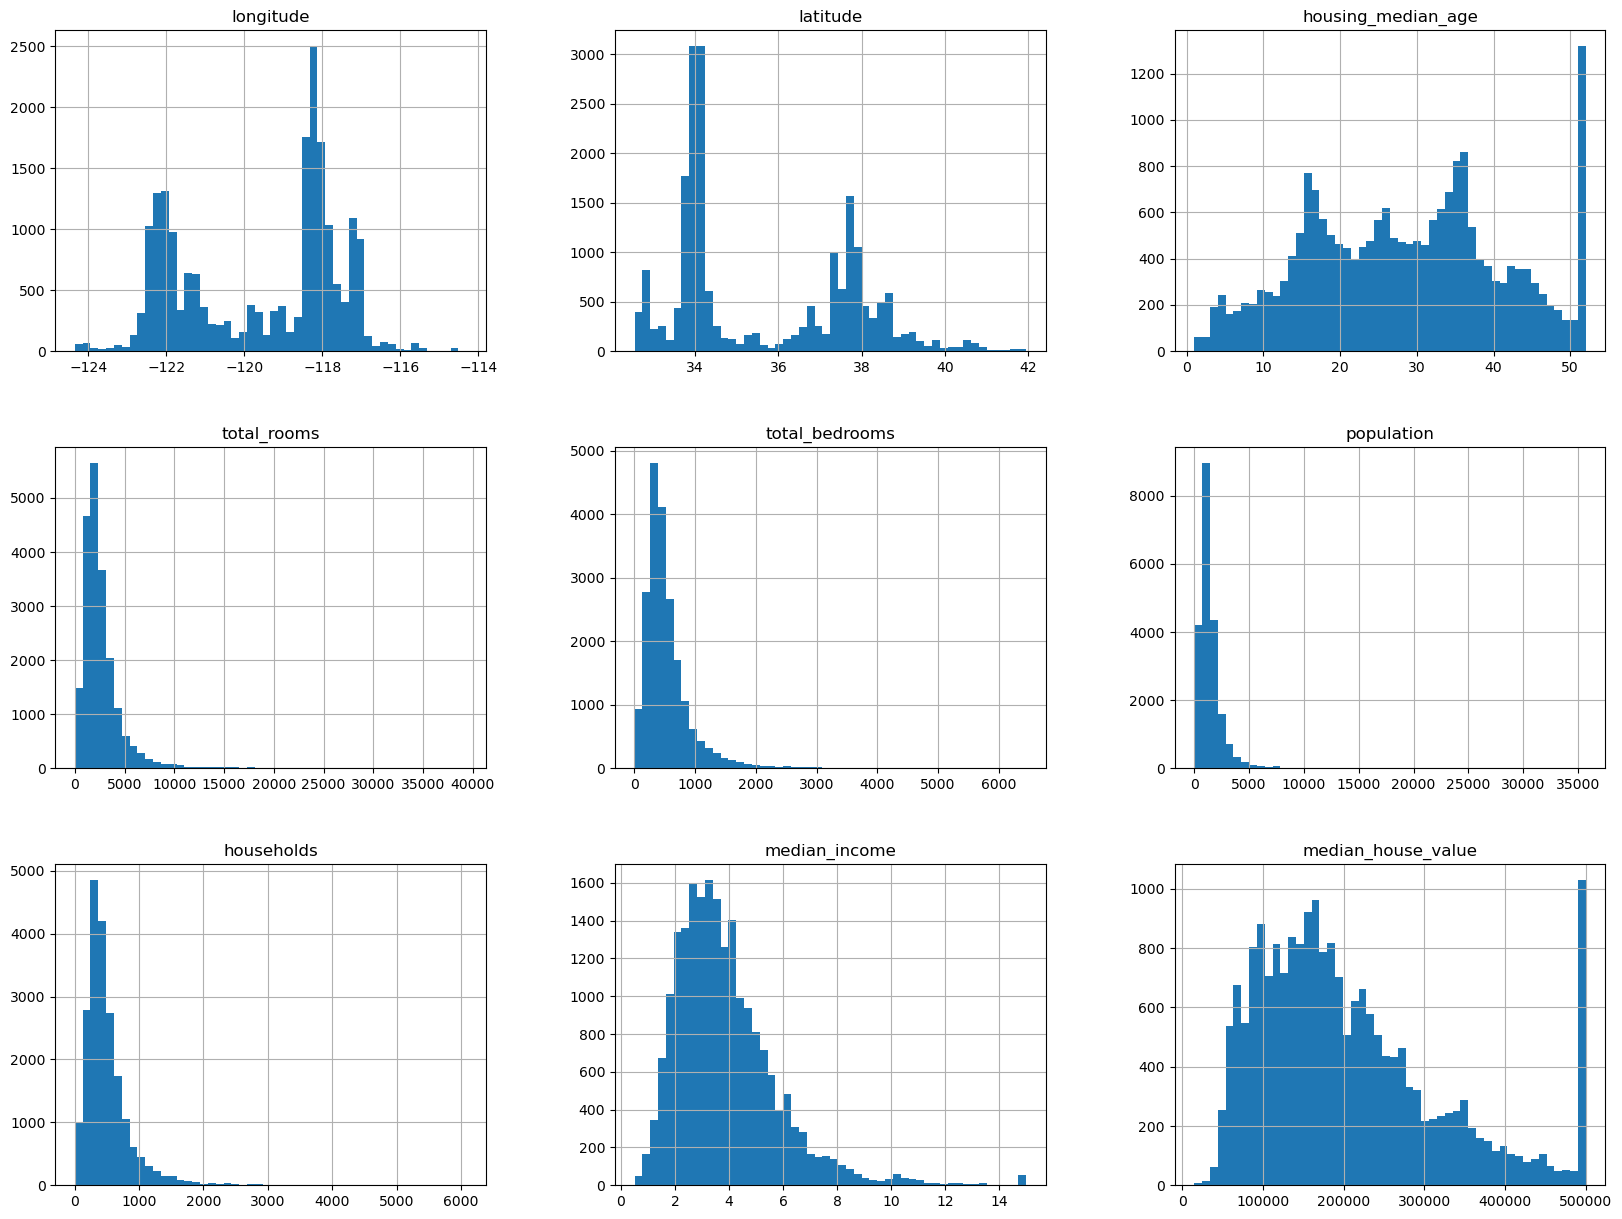

In [14]:
housing.hist(bins=50,figsize=(20,15))
plt.show()

# the inferences we can make from the above histograms
1. First the median income attributes does not look like it is expressed in US dollars(USD). After checking with the team that collecte the data, i m told that the data has been scaled and cape at 15 (actually 15.0001) for higher median incomes, and at 0.5 (actually 0.4999) for lower median incomes. The numbers represent roughly tens of thousand of dollars (e.g., 3 actually means about $30,000). Working with preprocessed attributes is common in Machine Learning, and it is not necessarily a problem, but you should tru to undestand how the data was computed.

2. The housing medin age and the medain house value were also capped. The later may be a serious problem since it is your target attribute (your labels).Your Machine Learning algorithms may learn that prices never go beyond that limit. You need to chek with your clietn team(the team that will use your system's  output) to see if this is a problem or not. If they tell you that they need precise predictions even beyond $500,000, then you have mainly two options:
a. Collect proper labels for the districts whose labels were capped.

b. Remove those districts from the training set (and also from the test set, since you system should not be evaluated poorly if it predicts values beyond $500,000).

3. These attributes have very different scales.
4. Finally, many histograms are tail heavy.: they extend much farther to the right of the median than to the left. This may make it a bit harder for some Machine Learning algorithms to detect patterns. We will try transforming these attributes later on to have more bell-shaped distributions.


Thus, Hopefully you now have a better understanding of the kind of data you are dealing with.


# Create a test set
data snooping bias: When you estimate the generalization error using the test set, your estimate will be too optimistic an you will launch a system that will not perform as well as expected. This is called data snooping bias.

In [15]:
# The manual method of splitting
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

Well the above block manual method of train test spllit works, but it it not perfect: if you run the program again, it will generate a different test set! OVer time, you (or your Machine Learning algorithms) will get to see the whole dataset, which is wht you want to avoid.
One solution to the above issue is to save the test set on the first run and then load it in subsequent runs. Another option is to set the radnom number generator's seed (e.g., np.random.seed(42)) before calling  np.random.permutation(), so that it always generates the sme shuffled indices.


But both these solutions will break next time you fetch an updated dataset. A commonn solution is to use ech instance's identifier and put that instance in the test set (assuming instances have a unique and immutable identifier). For example, you could compute  hash of each instance's identifier and dput that instance in the test set if the hash is lowewr or equal to 20% of the maximum hash value. This ensures that the test set will remain consistent across multiple runs, even if you refesh the dataset. The new test set will contain 20% of the new instances, but it will not contain any instance that was previously in the training set. Here is a possible implementation.

In [16]:
from zlib import crc32

def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio *2*32
def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]
    
    

In [17]:
# #If we use the row index as a uniquq identifier, you need to make sure that new data get appended to the end of the dataset, nd no row ever gets deleted.


housing_with_id = housing.reset_index()# adds an `index` column
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2,"index")

The above done method needs some conditions to be satisfied to be applicable successfully
we can go for this underlying method  which is the most stable features to build a unique identifier.
For example, a district's latitude and longitude are guaranteed to be stable for a few million years, so i could combine them into an ID like so.

In [18]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id,0.2,"id")

In [19]:
housing_with_id.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,-122192.12
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,-122182.14
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,-122202.15
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,-122212.15
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122212.15


The above done is manual derivation of the train_test_split function.
Scikit learn also provides us with this sort of function with a couple of additional features.First there is a random_state parameter that allows you to set the random generator seed as explained previously, and second you can pass it multiple datasets with an identical number of rows, and it will split them on the same indices (this is very useful, for example, if you have a separate DataFrame for lables):

In [20]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

When a survey company decides to call 1,000 people to ask them a few questions, they don't just pick 1,000 people randomly in a phone book. They try to ensure that these 1,000 people are representative of the whole population. For example, the US  population is composed of 51.3% female and 48.7% male, so a well-conducted survey in the US would try to maintain this ratio in the sample: 513 female and 487 male. This is called stratified sampling: the population is divided into homogeneuos subgroups called strata and the right number of instances is sampled from eacg stratum to guarantee that the test set is representative of the overall population.
If they use purely random sampling, there would be about 12% chance of sampling a skewed test set with either less than 49% female or more than 54% female. Either way, the survey results would be significantly biased.

Suppose you chatted with experts who told you that the median income is a very important attribute to predict median housing prices. You may want to ensure that the test set is representative of the various categories of incomes in the whole dataset. Since the median income is a coninuous numerical attribute, you first need to create an income category attribute. Let's look at thte median income histogram more closely: most median income values are clusetered around 1.5 to 1.6(i.e., $15,000-$60,000), but some median incomes go far beyond 6. It is important to have  sufficient number of instances in your dataset for each stratum, or else the estimate of the stratum's importance may be biased. This means that you should not have too many strata, and each stratum should be large enough. The followwing code uses the pd.cut()  function to create an income category attribute with 5 categories (labeled from 1 to 5): category 1 ranges from 0 to 1.5(i.e., less than $15,000), caategory 2 from 1.5 to 3, and so on:

In [21]:
housing["income_cat"] = pd.cut(housing["median_income"],bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                              labels=[1,2,3,4,5])

<Axes: >

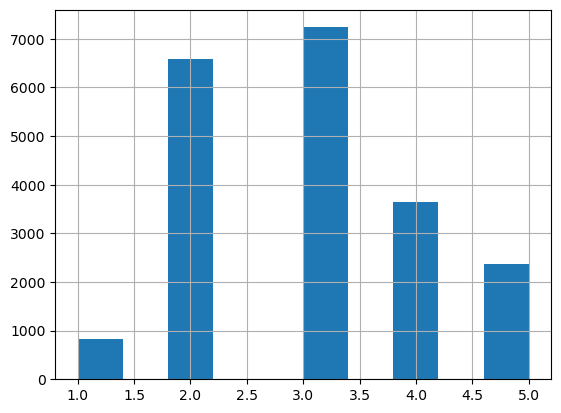

In [22]:
housing["income_cat"].hist()

In [25]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strate_test_set = housing.loc[test_index]

In [26]:
strat_test_set["income_cat"].value_counts() / len(strate_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [27]:
for set_ in (strat_train_set, strat_test_set):
 set_.drop("income_cat", axis=1, inplace=True)


## Discover and Visulaize the Data to Gain Insights

So far i have only taken a quick glance at the data to get a general understanding of the kind of data you are manipulating. Now the goal is to go a liitle bit more depth.

First maake sure you have put the test set side and you re only exploring the training set. Also, if the training set is very large, you may want to sample an exploration set, to make manipulations easy and fast. In the current projec case the set is quite small so you can just work directly on the full set. Let's create a copy so you can play with it without harming the training set:

In [28]:
housing = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

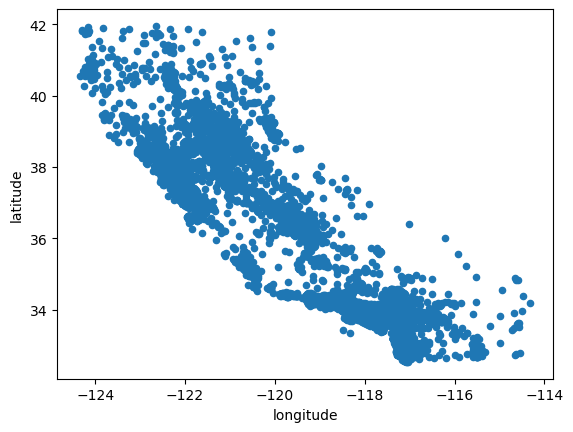

In [29]:
housing.plot(kind="scatter", x="longitude", y="latitude")

It is not easy to dtect the pattern here so

<Axes: xlabel='longitude', ylabel='latitude'>

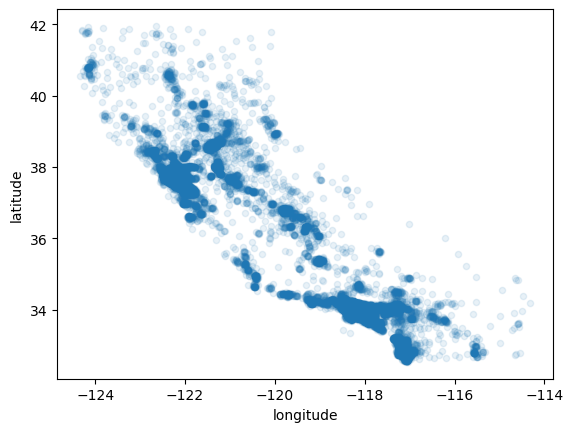

In [30]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

Now that'pretty good: i can clearly see the high-density areas, namely the Bay Area and around Los Angeles and San Diego plus a long line of fairly high density in the Central Valley, in particular around Sacramento and Fresno

Now let's look at the housing prices. The radius of each circle represents the district's population, and the color represents the price.


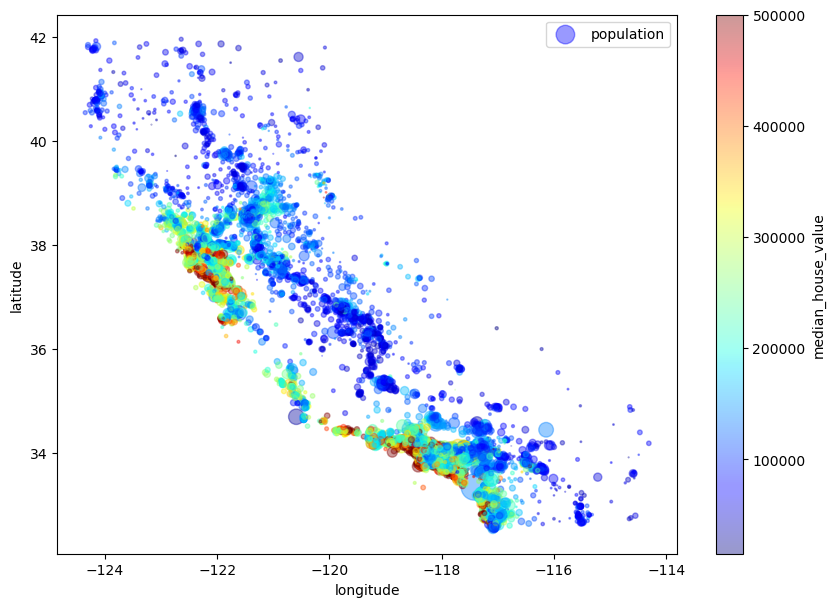

In [31]:
housing.plot(kind="scatter", x="longitude", y="latitude",alpha = 0.4,s=housing["population"]/100, label="population", figsize=(10,7), c="median_house_value", cmap=plt.get_cmap("jet"),colorbar= True,)
plt.legend()

Through this we can say that housing prices are very much related to the location(e.g., close to the ocean) and  to the population density, as you probably knew already. It will probably be useful to use a clustering algorithm to detect main clusters, and add new features that measure the proximity to the cluster centers. The ocean proximity attribute maybe useful as well, alhough in Northern California the housing prices in coastal districts are not too high, so it is not a simple rule.

## Looking for Correlations

Since the dataset is not too large, you can easily compute the standard correlation coefficient(also called Pearson's) between every pair of attributes using the corr() method:


In [32]:
corr_matrix = housing.corr()

ValueError: could not convert string to float: 'INLAND'